In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from episbi.models import Transition, compartment_model
from episbi.prior import UniformPrior
from episbi.inference import SBIEngine
from episbi import simulate_for_sbi
from episbi.metric import evaluate_prediction_windows
from episbi.utils import plot_prediction_windows

/etc/python/sitecustomize.py:117: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  mod = _original_import(name, globals, locals, fromlist, level)


In [2]:
model_type = "deterministic"
simulator_extra_kwargs = {"observation_error": "poisson"}
simulation_cpu_cores = 16
num_simulations = 10_000
num_posterior_samples = 1_000

initial_conditions = {'S': 99_990, 'E': 0, 'I': 10, 'A': 0, 'R': 0}
theta_true = {'beta_I': 0.8, 'beta_A': 0.35, 'k': 0.3, 'rho': 0.65, 'gamma': 0.2}
total_days = 100
inference_days = 90
forecast_days = total_days - inference_days
output_names = ['E_to_I']

In [3]:
model = compartment_model(
    compartments=['S', 'E', 'I', 'A', 'R'],
    transitions=[
        Transition('S', 'E', '(beta_A * A + beta_I * I) * S / N', name='S_to_E'),
        Transition('E', 'I', 'k * rho * E', name='E_to_I'),
        Transition('E', 'A', 'k * (1 - rho) * E', name='E_to_A'),
        Transition('I', 'R', 'gamma * I', name='I_to_R'),
        Transition('A', 'R', 'gamma * A', name='A_to_R'),
    ],
    param_names=['beta_I', 'beta_A', 'k', 'rho', 'gamma'],
    model_type=model_type,
    initial_conditions=initial_conditions,
    observed={"transitions": output_names},
)

print(model.show())

Model type: deterministic
Compartments: S, E, I, A, R
Parameters: beta_I, beta_A, k, rho, gamma
Transitions:
  S_to_E: S -> E, rate=(beta_A * A + beta_I * I) * S / N
  E_to_I: E -> I, rate=k * rho * E
  E_to_A: E -> A, rate=k * (1 - rho) * E
  I_to_R: I -> R, rate=gamma * I
  A_to_R: A -> R, rate=gamma * A
Observed:
  E_to_I


In [4]:
prior = UniformPrior(
    {
        'beta_I': (0.2, 1.2),
        'beta_A': (0.05, 0.8),
        'k': (0.1, 0.6),
        'rho': (0.3, 0.9),
        'gamma': (0.05, 0.5),
    }
)

In [5]:
thetas, xs = simulate_for_sbi(
    prior=prior,
    simulator=model,
    num_simulations=num_simulations,
    total_days=total_days,
    seed=0,
    simulator_kwargs=simulator_extra_kwargs,
    n_jobs=simulation_cpu_cores,
)

thetas_train = thetas
xs_train = xs[:, :inference_days, :]

thetas.shape, xs.shape, xs_train.shape

((10000, 5), (10000, 100, 1), (10000, 90, 1))

In [6]:
observed_result = model(
    theta_true,
    total_days=total_days,
    seed=0,
    **simulator_extra_kwargs,
)

observed = {name: observed_result[name] for name in output_names}
obs_train = {name: values[:inference_days] for name, values in observed.items()}
observed_array = np.column_stack([observed[name] for name in output_names])
obs_train_array = observed_array[:inference_days]

observed_array.shape, obs_train_array.shape, observed_result.keys()

((100, 1), (90, 1), dict_keys(['E_to_I']))

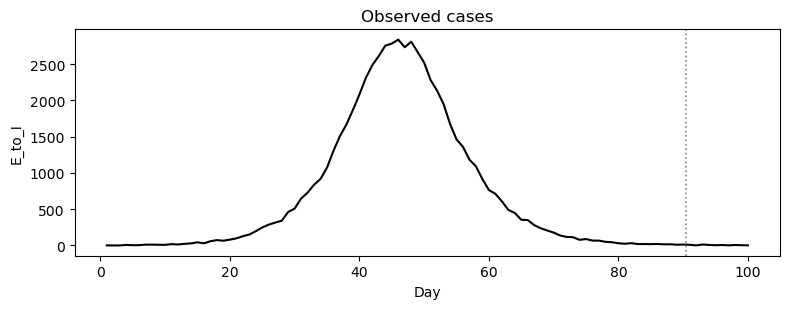

In [7]:
days = np.arange(1, total_days + 1)
fig, axes = plt.subplots(len(output_names), 1, figsize=(8, 3.2 * len(output_names)), sharex=True)

if len(output_names) == 1:
    axes = [axes]

for ax, name in zip(axes, output_names):
    ax.plot(days, observed[name], color="black", linewidth=1.5)
    ax.axvline(inference_days + 0.5, color="gray", linestyle=":", linewidth=1.2)
    ax.set_ylabel(name)
    ax.set_title(f"Observed cases")

axes[-1].set_xlabel("Day")
fig.tight_layout()
plt.show()

## Inference - NPE

In [8]:
engine = SBIEngine(batch_size=256)
npe_result = engine.run_npe(
    obs_data=obs_train,
    prior=prior,
    thetas=thetas_train,
    xs=xs_train,
    input_dim=len(output_names),
    num_samples=num_posterior_samples,
    show_train_summary=False,
)

posterior = npe_result["posterior"]
posterior_samples = npe_result["samples"].detach().cpu().numpy()
posterior_samples.shape

[*] Running NPE (use_lstm=False) with batch size 256...
 Neural network successfully converged after 215 epochs.

1036it [00:00, 23307.06it/s]            


(1000, 5)

In [9]:
param_df = pd.DataFrame(np.asarray(posterior_samples), columns=prior.names)
param_df.describe()

,beta_I,beta_A,k,rho,gamma
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.813603,0.434706,0.327625,0.662226,0.221756
std,0.161428,0.155010,0.097845,0.021998,0.052394
min,0.492432,0.056972,0.107384,0.610348,0.050567
25%,0.686681,0.326462,0.254527,0.646175,0.183953
50%,0.804931,0.437398,0.323203,0.660894,0.221988
75%,0.932496,0.544783,0.396144,0.677010,0.256150
max,1.195098,0.793785,0.599374,0.743444,0.398325


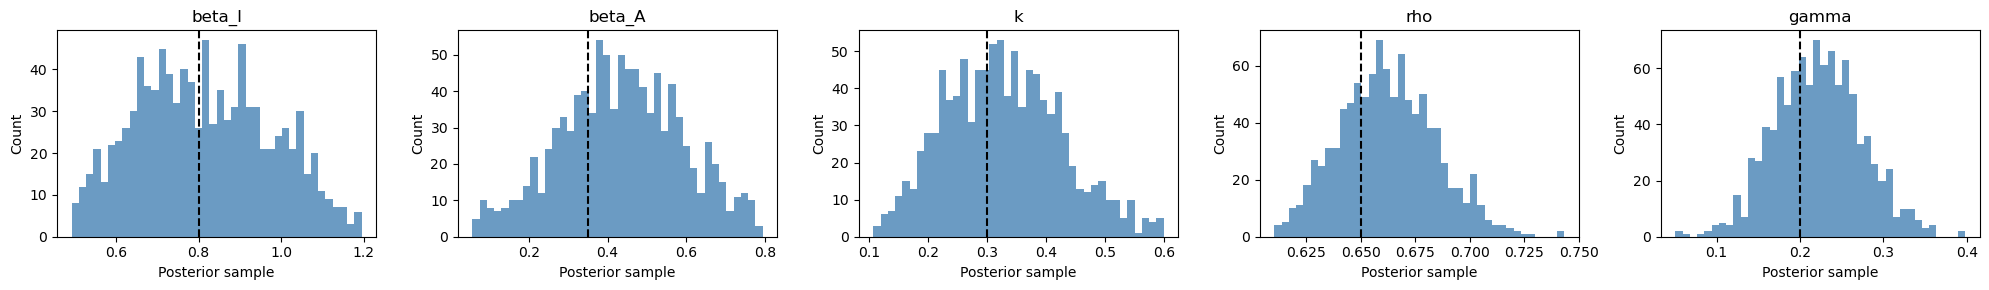

In [10]:
fig, axes = plt.subplots(1, len(prior.names), figsize=(4 * len(prior.names), 3))

if len(prior.names) == 1:
    axes = [axes]

for ax, name in zip(axes, prior.names):
    ax.hist(param_df[name], bins=40, color="steelblue", alpha=0.8)
    ax.axvline(theta_true[name], color="black", linestyle="--", linewidth=1.5)
    ax.set_title(name)
    ax.set_xlabel("Posterior sample")
    ax.set_ylabel("Count")

fig.tight_layout()
plt.show()

In [11]:
posterior_predictive = []

for _, theta in param_df.iloc[:300].iterrows():
    theta_dict = prior.to_dict(theta)
    sim = model(
        theta_dict,
        total_days=total_days,
        **simulator_extra_kwargs,
    )
    posterior_predictive.append(np.column_stack([sim[name] for name in output_names]))

posterior_predictive = np.stack(posterior_predictive)
posterior_predictive.shape

(300, 100, 1)

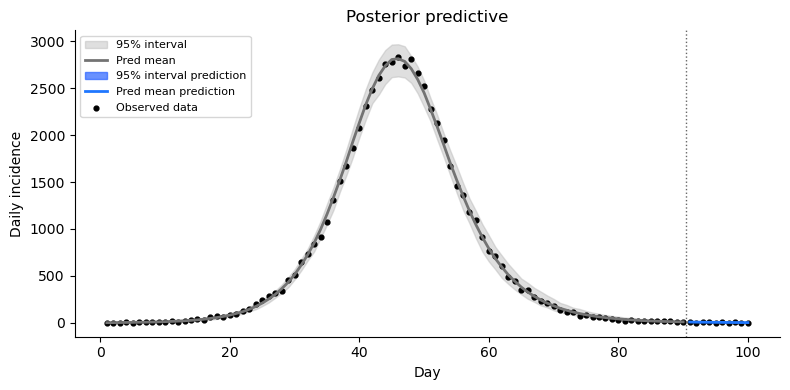

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_prediction_windows(
    y_obs=observed[output_names[0]],
    prediction=posterior_predictive,
    inference_days=inference_days,
    forecast_days=forecast_days,
    output_index=0,
    title=f"Posterior predictive",
    ax=ax,
)
fig.tight_layout()
plt.show()

In [14]:
ppc_result = evaluate_prediction_windows(
    y_obs=observed[output_names[0]],
    prediction=posterior_predictive,
    inference_days=inference_days,
    forecast_days=forecast_days,
    output_names=["incidence"],
)

ppc_result

,window,output,MAE,RMSE,PI95_coverage,interval_score,WIS
0,inference,incidence,18.361111,28.336127,0.966667,135.296944,47.942410
1,forecast,incidence,2.600000,3.316625,0.900000,13.657500,5.908061
